
# Quarterback Decision–Making Model



### Imports

In [215]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, brier_score_loss, mean_squared_error, classification_report, brier_score_loss
from sklearn.calibration import calibration_curve
from scipy.stats import pearsonr

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier, MLPRegressor

import os


## Data Import and Processing


### Data Imports


In [216]:
EXPERIMENT_NAME = "V_1"

raw_features = pd.read_csv("../data/play_features.csv")
outcomes = pd.read_csv("../data/play_outcomes.csv")

features = raw_features.rename(columns={"gameId": "game_id", "playId": "play_id", "frameId": "frame_id"})

C:\Users\jesse\AppData\Local\Temp\ipykernel_11148\3590233958.py:3: DtypeWarning: Columns (0,3,4,5,6,7,8,9,10,11,14,15,16,17,18,19,20,21,22,25,26,27,28,29,30,31,32,33,36,37,38,39,40,41,42,43,44,47,48,49,50,51,52,53,54,55,58,59,60,61,62,63,64,65,66,69,70,71,72,73,74,75,76,77,80,81,82,83,84,85,86,87,88,91,92,93,94,95,96,97,98,99,102,103,104,105,106,107,108,109,110,113,114,115,116,117,118,119,120,121,124,125,126,127,128,129,130,131,132,135,136,137,138,139,140,141,142,143,146,147,148,149,150,151,152,153,154,157,158,159,160,161,162,163,164,165,168,169,170,171,172,173,174,175,176,179,180,181,182,183,184,185,186,187,190,191,192,193,194,195,196,197,198,201,202,203,204,205,206,207,208,209,212,213,214,215,216,217,218,219,220,223,224,225,226,227,228,229,230,231,234,235,236,237,238,239,240,241,242,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_features = pd.read_csv("../data/play_features.csv")


### Data Processing

In [217]:
# Ensure numeric types
for col in features.select_dtypes(include=['object']).columns:
    features[col] = pd.to_numeric(features[col], errors='coerce')

for col in ["game_id", "play_id", "targeted_receiver_nflId", "start_frame", "end_frame",
            "down", "yards_to_go", "line_of_scrimmage", "yards_gained", "time_to_throw"]:
    outcomes[col] = pd.to_numeric(outcomes[col], errors='coerce')


In [218]:
# Filter valid pass results
outcomes = outcomes[outcomes["pass_result"].isin(["C", "I", "IN"])]



### Add Target Recievers

In [219]:
# Merge to get targeted_receiver_nflId
features = features.merge(outcomes[["game_id", "play_id", "targeted_receiver_nflId"]], on=["game_id", "play_id"], how="left")

# Get index of targeted receiver (players 6 to 10)
def get_receiver_index(row):
    for i in range(6, 11):
        if row.get(f"player_{i}_nflId") == row["targeted_receiver_nflId"]:
            return i - 6
    return -1

features["target_receiver_index"] = features.apply(get_receiver_index, axis=1)
features = features[features["target_receiver_index"] != -1].copy()


In [220]:
# Merge end_frame, filter to final frame
features = features.merge(outcomes[["game_id", "play_id", "end_frame"]], on=["game_id", "play_id"], how="left")
features = features[features["frame_id"] == features["end_frame"]].copy()
features.drop(columns=["end_frame"], inplace=True)


In [221]:
receiver_attrs = ['x', 'x_relative', 'y', 's', 'a', 'dis', 'o', 'dir']
targeted_features = []

for idx, row in features.iterrows():
    idx_target = int(row["target_receiver_index"])
    if 0 <= idx_target <= 4:
        f_row = [row.get(f"player_{idx_target + 6}_{attr}", 0.0) for attr in receiver_attrs]
    else:
        f_row = [0.0] * len(receiver_attrs)
    targeted_features.append(f_row)

targeted_df = pd.DataFrame(targeted_features, columns=[f"target_{attr}" for attr in receiver_attrs])
features = pd.concat([features.reset_index(drop=True), targeted_df], axis=1)


In [222]:
features = features.merge(outcomes, on=['game_id', 'play_id'], how='left')
features["frames_from_snap"] = features["frame_id"] - features["start_frame"]



In [223]:
# Drop non-numeric, identifier, or irrelevant fields
cols_to_drop = [col for col in features.columns 
                if col.endswith("displayName_x") or col.endswith("nflId") 
                or col.endswith("_position") or col.endswith("displayName_y")
                or col in ["start_frame", "end_frame", "game_id", "play_id", "frame_id",
                           "yards_gained", "pass_result", "play_type", "targeted_receiver_nflId",
                           "player_22_nflId", "player_22_position", "player_22_o", "player_22_dir", 
                           "time_to_throw", "targeted_receiver", "player22_dir", "player22_position", 
                           "player22_displayName_y"]]




In [224]:
# Classification dataset
clf_df = features.dropna(subset=["pass_result"]).copy()
X_clf = clf_df.drop(columns=cols_to_drop)
y_clf = clf_df["pass_result"]
le = LabelEncoder()
y_clf_enc = le.fit_transform(y_clf)  # ["C", "I", "IN"] → [0, 1, 2]

# Regression dataset (only completions)
reg_df = features[features["pass_result"] == "C"].copy()
X_reg = reg_df.drop(columns=cols_to_drop)
y_reg = reg_df["yards_gained"]

### Train Test Split

In [225]:
# 5) Scale features
scaler_c = StandardScaler().fit(X_clf)
Xc_s = scaler_c.transform(X_clf)

scaler_r = StandardScaler().fit(X_reg)
Xr_s = scaler_r.transform(X_reg)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc_s, y_clf_enc, test_size=0.2, random_state=42, stratify=y_clf_enc
)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr_s, y_reg, test_size=0.2, random_state=42
)

In [226]:


# Convert to torch tensors
Xc_train_tensor = torch.tensor(Xc_train, dtype=torch.float32)
Xc_test_tensor  = torch.tensor(Xc_test, dtype=torch.float32)
yc_train_tensor = torch.tensor(yc_train, dtype=torch.long)
yc_test_tensor  = torch.tensor(yc_test, dtype=torch.long)

Xr_train_tensor = torch.tensor(Xr_train, dtype=torch.float32)
Xr_test_tensor  = torch.tensor(Xr_test, dtype=torch.float32)
yr_train_tensor = torch.tensor(yr_train.values, dtype=torch.float32).unsqueeze(1)
yr_test_tensor  = torch.tensor(yr_test.values, dtype=torch.float32).unsqueeze(1)

## Model Architecture

In [283]:
class Net(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Net, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 230),
            nn.ReLU(),
            nn.BatchNorm1d(230),

            nn.Dropout(0.4),
            nn.Linear(230, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.layers(x)

In [284]:
# Model 1 (classification)
clf_model = Net(Xc_train.shape[1], 3)
optimizer_clf = optim.Adam(clf_model.parameters(), lr=1e-3)
criterion_clf = nn.CrossEntropyLoss()

# (Train loop + loss tracking and test evaluation)

## 7. 🚂 Train Regressor
# Model 2 (regression)
reg_model = Net(Xr_train.shape[1], 1)
optimizer_reg = optim.Adam(reg_model.parameters(), lr=1e-3)
criterion_reg = nn.MSELoss()


## Training

### Classification Model Training


In [285]:


train_losses, test_losses = [], []
train_acc, test_acc = [], []


for epoch in range(25):
    clf_model.train()
    optimizer_clf.zero_grad()
    outputs = clf_model(Xc_train_tensor)
    
    loss = criterion_clf(outputs, yc_train_tensor)
    loss.backward()
    optimizer_clf.step()
    train_losses.append(loss.item())

    # get accuracy
    class_probs = torch.softmax(outputs, dim=1)
    class_preds = torch.argmax(class_probs, dim=1)
    total_correct = (class_preds == yc_train_tensor).sum().item()
    total_class = yc_train_tensor.size(0)
    train_acc.append(total_correct / total_class)

    # Evaluate
    clf_model.eval()
    with torch.no_grad():
        val_outputs = clf_model(Xc_test_tensor)
        val_loss = criterion_clf(val_outputs, yc_test_tensor).item()
        test_losses.append(val_loss)
            # get accuracy
        class_probs = torch.softmax(val_outputs, dim=1)
        class_preds = torch.argmax(class_probs, dim=1)
        total_correct = (class_preds == yc_test_tensor).sum().item()
        total_class = yc_test_tensor.size(0)
        test_acc.append(total_correct / total_class)


    print(f"Epoch {epoch+1}: Train Loss = {loss.item():.4f}, Train Accuracy = {train_acc[-1]:.4f}, Test Loss = {val_loss:.4f}, Test Accuracy = {total_correct / total_class:.4f}")

# Save model

torch.save(clf_model.state_dict(), "../models/throw_classifier_v1.pt")


Epoch 1: Train Loss = 1.0791, Train Accuracy = 0.4432, Test Loss = 1.0641, Test Accuracy = 0.5472
Epoch 2: Train Loss = 1.0117, Train Accuracy = 0.5621, Test Loss = 1.0514, Test Accuracy = 0.5760
Epoch 3: Train Loss = 0.9510, Train Accuracy = 0.6311, Test Loss = 1.0357, Test Accuracy = 0.6077
Epoch 4: Train Loss = 0.9056, Train Accuracy = 0.6450, Test Loss = 1.0162, Test Accuracy = 0.6310
Epoch 5: Train Loss = 0.8577, Train Accuracy = 0.6677, Test Loss = 0.9934, Test Accuracy = 0.6555
Epoch 6: Train Loss = 0.8213, Train Accuracy = 0.6726, Test Loss = 0.9676, Test Accuracy = 0.6687
Epoch 7: Train Loss = 0.7924, Train Accuracy = 0.6746, Test Loss = 0.9394, Test Accuracy = 0.6794
Epoch 8: Train Loss = 0.7610, Train Accuracy = 0.6858, Test Loss = 0.9094, Test Accuracy = 0.6866
Epoch 9: Train Loss = 0.7349, Train Accuracy = 0.6931, Test Loss = 0.8785, Test Accuracy = 0.6878
Epoch 10: Train Loss = 0.7141, Train Accuracy = 0.6949, Test Loss = 0.8482, Test Accuracy = 0.6830
Epoch 11: Train Los

### Regression Model Training


In [286]:


reg_train_losses, reg_test_losses = [], []

for epoch in range(40):
    reg_model.train()
    optimizer_reg.zero_grad()
    preds = reg_model(Xr_train_tensor)
    loss = criterion_reg(preds, yr_train_tensor)
    loss.backward()
    optimizer_reg.step()
    reg_train_losses.append(loss.item())

    # Evaluate
    reg_model.eval()
    with torch.no_grad():
        val_preds = reg_model(Xr_test_tensor)
        val_loss = criterion_reg(val_preds, yr_test_tensor).item()
        reg_test_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {loss.item():.4f}, Test Loss = {val_loss:.4f}")

# Save model
torch.save(reg_model.state_dict(), "../models/throw_regressor_v1.pt")


Epoch 1: Train Loss = 218.9617, Test Loss = 233.6929
Epoch 2: Train Loss = 215.2935, Test Loss = 232.9013
Epoch 3: Train Loss = 211.6046, Test Loss = 231.9094
Epoch 4: Train Loss = 207.8107, Test Loss = 230.5524
Epoch 5: Train Loss = 203.8742, Test Loss = 228.6420
Epoch 6: Train Loss = 198.9767, Test Loss = 225.9781
Epoch 7: Train Loss = 193.7105, Test Loss = 222.3242
Epoch 8: Train Loss = 187.9186, Test Loss = 217.4222
Epoch 9: Train Loss = 181.9767, Test Loss = 211.0701
Epoch 10: Train Loss = 174.9474, Test Loss = 203.0838
Epoch 11: Train Loss = 167.0332, Test Loss = 193.5011
Epoch 12: Train Loss = 160.1452, Test Loss = 182.5290
Epoch 13: Train Loss = 151.7478, Test Loss = 170.5676
Epoch 14: Train Loss = 144.0253, Test Loss = 158.1514
Epoch 15: Train Loss = 136.1689, Test Loss = 145.9081
Epoch 16: Train Loss = 128.8031, Test Loss = 134.4513
Epoch 17: Train Loss = 119.9565, Test Loss = 124.0784
Epoch 18: Train Loss = 113.3314, Test Loss = 115.0554
Epoch 19: Train Loss = 106.2478, Test

## Plots

### Training Loss Plots

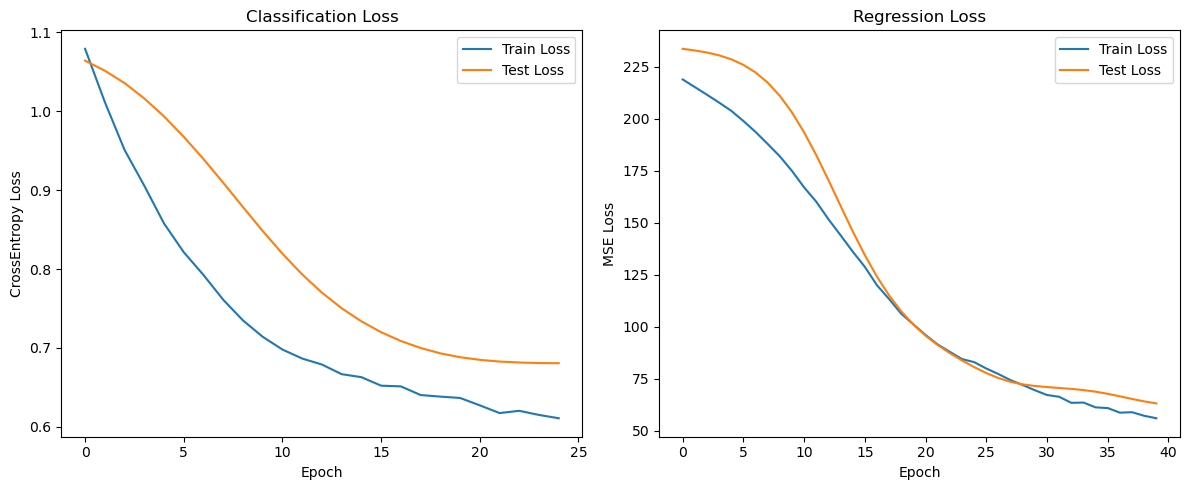

In [287]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("CrossEntropy Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(reg_train_losses, label="Train Loss")
plt.plot(reg_test_losses, label="Test Loss")
plt.title("Regression Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.tight_layout()
plt.show()


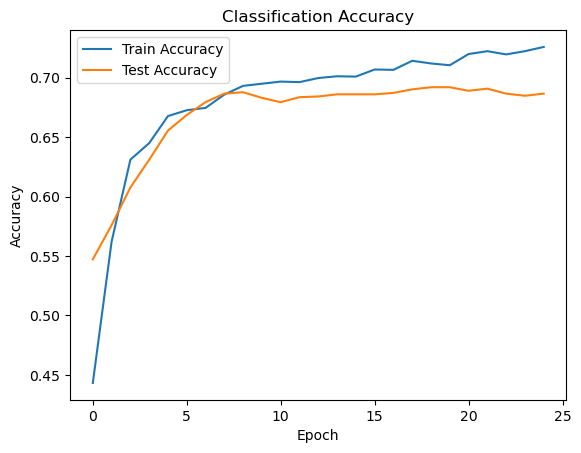

In [288]:
plt.plot(train_acc, label="Train Accuracy")
plt.plot(test_acc, label="Test Accuracy")
plt.title("Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### Classification Prediction and Calibration


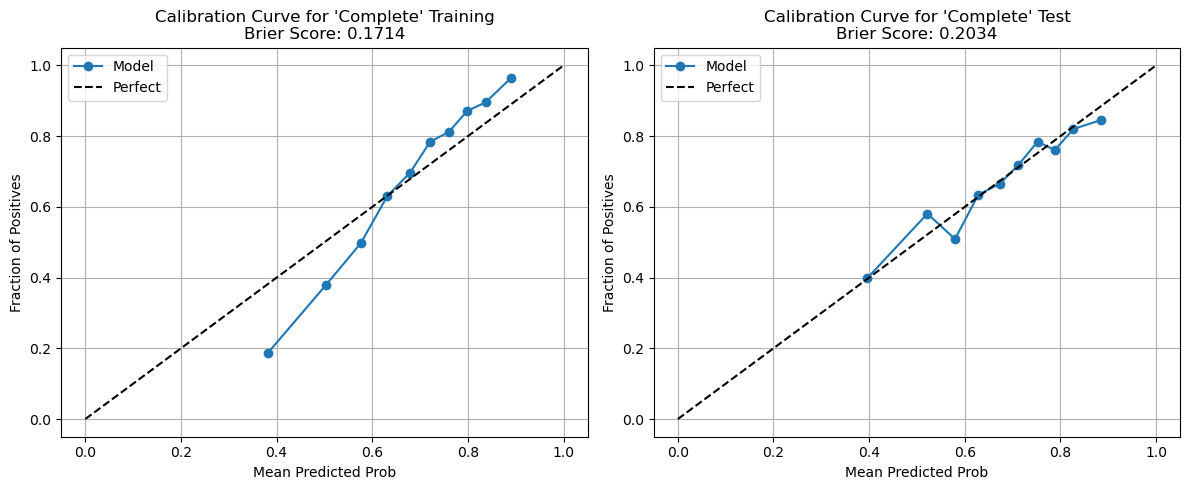

In [289]:
clf_model.eval()
with torch.no_grad():
    logits = clf_model(Xc_train_tensor)
    train_probs = torch.softmax(logits, dim=1).numpy()

    logits = clf_model(Xc_test_tensor)
    test_probs = torch.softmax(logits, dim=1).numpy()

# Calibration curve (Complete class, index 0)
from sklearn.calibration import calibration_curve

train_true_complete = (yc_train == 0).astype(int)
train_prob_complete = train_probs[:, 0]

test_true_complete = (yc_test == 0).astype(int)
test_prob_complete = test_probs[:, 0]

frac_pos, mean_pred = calibration_curve(train_true_complete, train_prob_complete, n_bins=10, strategy='quantile')
brier = brier_score_loss(train_true_complete, train_prob_complete)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mean_pred, frac_pos, 'o-', label="Model")
plt.plot([0, 1], [0, 1], 'k--', label="Perfect")
plt.title(f"Calibration Curve for 'Complete' Training\nBrier Score: {brier:.4f}")
plt.xlabel("Mean Predicted Prob")
plt.ylabel("Fraction of Positives")
plt.grid(True)
plt.legend()


frac_pos, mean_pred = calibration_curve(test_true_complete, test_prob_complete, n_bins=10, strategy='quantile')
brier = brier_score_loss(test_true_complete, test_prob_complete)


plt.subplot(1, 2, 2)
plt.plot(mean_pred, frac_pos, 'o-', label="Model")
plt.plot([0, 1], [0, 1], 'k--', label="Perfect")
plt.title(f"Calibration Curve for 'Complete' Test\nBrier Score: {brier:.4f}")
plt.xlabel("Mean Predicted Prob")
plt.ylabel("Fraction of Positives")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.show()


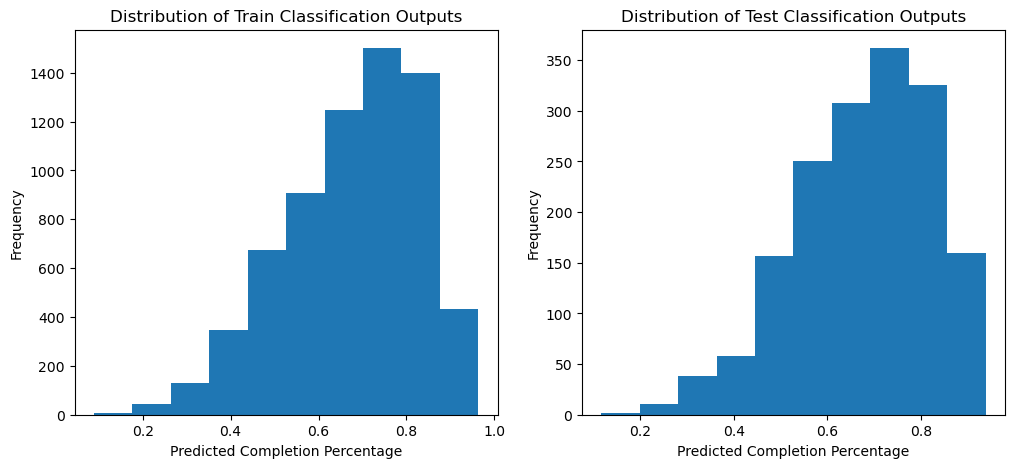

In [290]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.hist(train_prob_complete)

plt.xlabel("Predicted Completion Percentage")
plt.ylabel("Frequency")
plt.title("Distribution of Train Classification Outputs")

plt.subplot(1, 2, 2)

plt.hist(test_prob_complete)

plt.xlabel("Predicted Completion Percentage")
plt.ylabel("Frequency")
plt.title("Distribution of Test Classification Outputs")
plt.show()

### Regression scatter plot + correlation

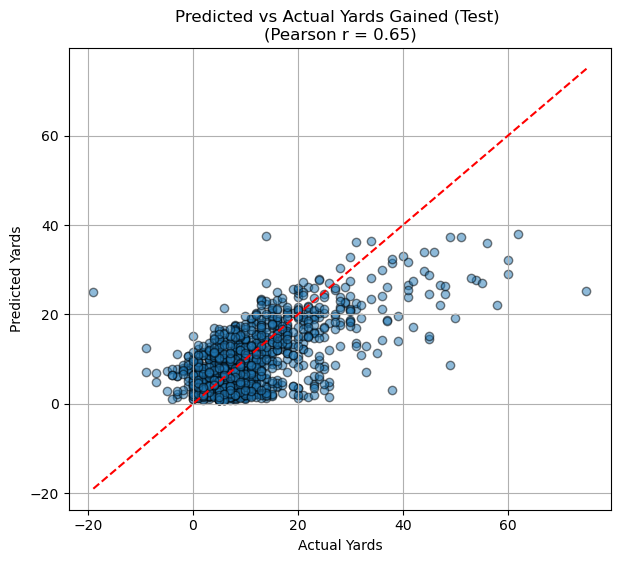

In [291]:
reg_model.eval()
with torch.no_grad():
    r_preds = reg_model(Xr_test_tensor).squeeze().numpy()

from scipy.stats import pearsonr
r_corr, _ = pearsonr(yr_test, r_preds)

plt.figure(figsize=(7, 6))
plt.scatter(yr_test, r_preds, alpha=0.5, edgecolors='k')
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--')
plt.title(f"Predicted vs Actual Yards Gained (Test) \n(Pearson r = {r_corr:.2f})")
plt.xlabel("Actual Yards")
plt.ylabel("Predicted Yards")
plt.grid(True)
plt.show()


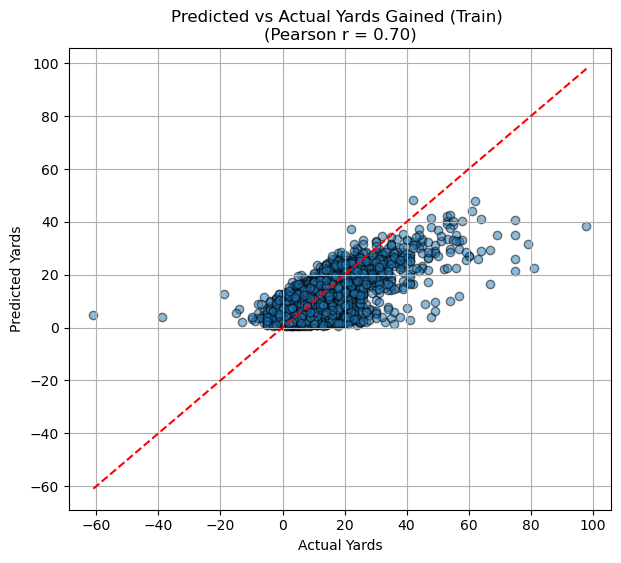

In [292]:
reg_model.eval()
with torch.no_grad():
    r_preds = reg_model(Xr_train_tensor).squeeze().numpy()

from scipy.stats import pearsonr
r_corr, _ = pearsonr(yr_train, r_preds)

plt.figure(figsize=(7, 6))
plt.scatter(yr_train, r_preds, alpha=0.5, edgecolors='k')
plt.plot([yr_train.min(), yr_train.max()], [yr_train.min(), yr_train.max()], 'r--')
plt.title(f"Predicted vs Actual Yards Gained (Train) \n(Pearson r = {r_corr:.2f})")
plt.xlabel("Actual Yards")
plt.ylabel("Predicted Yards")
plt.grid(True)
plt.show()

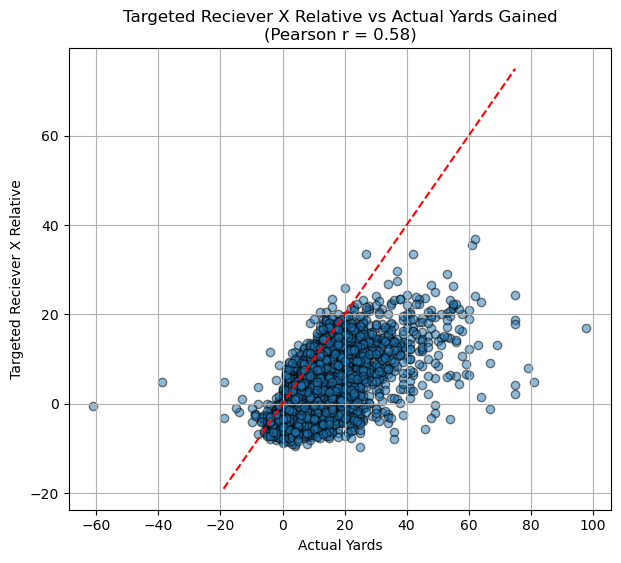

In [293]:
from scipy.stats import pearsonr
completed = features[features["pass_result"] == "C"]
r_corr, _ = pearsonr(completed["yards_gained"], completed["target_x_relative"])

plt.figure(figsize=(7, 6))
plt.scatter(completed["yards_gained"], completed["target_x_relative"], alpha=0.5, edgecolors='k')
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--')
plt.title(f"Targeted Reciever X Relative vs Actual Yards Gained\n(Pearson r = {r_corr:.2f})")
plt.xlabel("Actual Yards")
plt.ylabel("Targeted Reciever X Relative")
plt.grid(True)
plt.show()

# QB Analysis


In [294]:
from collections import defaultdict

qb_metrics = defaultdict(dict)

# Get unique QB ids
qb_ids = raw_features["player_0_nflId"].unique()


In [295]:
for qb_id in qb_ids:
    # Filter rows for this QB
    qb_mask = features["player_0_nflId"] == qb_id
    qb_rows = Xc_s[qb_mask]
    
    if len(qb_rows) == 0:
        continue

    # Get relevant model inputs
    X_clf_qb = Xc_s[qb_mask]
    y_true_class = y_clf_enc[qb_mask]

    qb_mask = reg_df["player_0_nflId"] == qb_id
    X_reg_qb = Xr_s[qb_mask]
    y_true_reg = y_reg[qb_mask].reset_index(drop=True)

    # Convert to tensor
    X_clf_tensor = torch.tensor(X_clf_qb, dtype=torch.float32)
    X_reg_tensor = torch.tensor(X_reg_qb, dtype=torch.float32)


    # Run through model
    with torch.no_grad():
        logits = clf_model(X_clf_tensor)
        yards_pred = reg_model(X_reg_tensor)
        probs = torch.softmax(logits, dim=1).numpy()
        class_preds = torch.argmax(logits, dim=1).numpy()
        reg_preds = yards_pred.squeeze().numpy()
    
    # === Completion Metrics ===
    actual_completion = (y_true_class == 0).mean()
    expected_completion = probs[:, 0].mean()

    # === Yards Gained ===
    actual_yards = y_true_reg.mean()
    expected_yards = reg_preds.mean()

    # === Save Basic Metrics ===
    qb_metrics[qb_id]["actual_completion"] = actual_completion
    qb_metrics[qb_id]["expected_completion"] = expected_completion
    qb_metrics[qb_id]["actual_yards"] = actual_yards
    qb_metrics[qb_id]["expected_yards"] = expected_yards
    qb_metrics[qb_id]["total_throws"] = len(X_clf_qb)



C:\Users\jesse\AppData\Local\Temp\ipykernel_11148\136520587.py:36: RuntimeWarning: Mean of empty slice.
  expected_yards = reg_preds.mean()
c:\Users\jesse\anaconda3\envs\nflenv\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [296]:
X_clf_index = X_clf.index
X_reg_index = X_reg.index

Xc_s_df = pd.DataFrame(Xc_s, index=X_clf_index, columns=X_clf.columns)

Xr_s_df = pd.DataFrame(Xr_s, index=X_reg_index, columns=X_reg.columns)


In [297]:
receiver_range = range(6, 11)
receiver_attrs = ['x', 'x_relative', 'y', 's', 'a', 'dis', 'o', 'dir']
real_results = []
fake_results = []

for qb_id in qb_ids:
    qb_mask = features["player_0_nflId"] == qb_id
    qb_rows = Xc_s_df[qb_mask].copy()

    total_plays = 0
    optimal_target_count = 0
    efficiency_sum = 0
    optimal_sum = 0

    for _, row in qb_rows.iterrows():
        if not 0 <= row["target_receiver_index"] <= 4:
            continue  # skip invalid

        base_input = Xc_s_df.loc[row.name].copy()  # original row
        target_idx = int(row["target_receiver_index"])

        candidate_values = []

        for i in range(5):
            receiver_idx = i + 6
            modified_row = base_input.copy()

            for attr in receiver_attrs:
                modified_row[f'target_{attr}'] = row[f'player_{receiver_idx}_{attr}']

            # Model prediction
            inp = torch.tensor(modified_row.values.reshape(1, -1), dtype=torch.float32)
            with torch.no_grad():
                output = clf_model(inp)
                class_probs = torch.softmax(output, dim=1)
                yp = reg_model(inp)
                candidate_values.append(yp.item() * class_probs[0, 0])
                if i == target_idx:
                    real_results.append([yp.item(), class_probs[0, 0]])
                else:
                    fake_results.append([yp.item(), class_probs[0, 0]])

        actual_value = candidate_values[target_idx].item()
        optimal_value = max(candidate_values).item()

        optimal_sum += optimal_value

        if np.argmax(candidate_values) == target_idx:
            optimal_target_count += 1

        if optimal_value > 0:
            efficiency_sum += actual_value / optimal_value

        total_plays += 1

    if total_plays > 0:
        qb_metrics[qb_id]["decision_efficiency_ratio"] = efficiency_sum / total_plays
        qb_metrics[qb_id]["optimal_target_rate"] = optimal_target_count / total_plays
        qb_metrics[qb_id]["average_optimal"] = optimal_sum / total_plays



In [298]:
# Create DataFrame from metrics
qb_results_df = pd.DataFrame.from_dict(qb_metrics, orient="index")
qb_results_df.reset_index(inplace=True)
qb_results_df.rename(columns={"index": "qb_nflId"}, inplace=True)

# Map QB display names using features
qb_id_to_name = raw_features.set_index("player_0_nflId")["player_0_displayName_x"].to_dict()
qb_results_df["qb_name"] = qb_results_df["qb_nflId"].map(qb_id_to_name)

# Add CPOE and YOE
qb_results_df["completion_over_expected"] = qb_results_df["actual_completion"] - qb_results_df["expected_completion"]
qb_results_df["yards_over_expected"] = qb_results_df["actual_yards"] - qb_results_df["expected_yards"]

# Filter QBs with at least 150 throws
qb_filtered = qb_results_df[qb_results_df["total_throws"] >= 150]

# Sort by completion over expected

# View top 10


In [302]:
qb_sorted = qb_filtered.sort_values("completion_over_expected", ascending=False)


qb_sorted[["qb_name", "expected_completion","completion_over_expected", "expected_yards", "yards_over_expected","average_optimal","optimal_target_rate", "decision_efficiency_ratio","total_throws"]].head(5)

,qb_name,expected_completion,completion_over_expected,expected_yards,yards_over_expected,average_optimal,optimal_target_rate,decision_efficiency_ratio,total_throws
26,Geno Smith,0.681683,0.062997,10.234237,0.731478,8.847773,0.173228,0.678555,235
16,Joe Burrow,0.661408,0.053336,9.251429,1.779962,8.132684,0.194245,0.665641,312
12,Matt Ryan,0.666909,0.052069,9.474220,0.459790,8.833417,0.166667,0.700645,274
0,Jalen Hurts,0.676906,0.039373,10.183173,2.141502,8.624441,0.180723,0.686752,215
10,Tua Tagovailoa,0.672925,0.039271,11.217596,1.933089,9.371182,0.166667,0.634018,205


In [305]:
qb_sorted[["qb_name", "expected_completion","completion_over_expected"]].head(5).style.hide(axis="index")


qb_name,expected_completion,completion_over_expected
Aaron Rodgers,0.699915,-0.025257
Davis Mills,0.685313,-0.035524
Russell Wilson,0.677344,-0.052344
Carson Wentz,0.702266,-0.054117
Justin Fields,0.660821,-0.065445


(array([1076.,  908.,  743.,  474.,  267.,  128.,   58.,   17.,    7.,
           2.]),
 array([ 0.58666813,  4.87687827,  9.16708841, 13.45729855, 17.74750869,
        22.03771883, 26.32792897, 30.61813911, 34.90834925, 39.19855939,
        43.48876953]),
 <BarContainer object of 10 artists>)

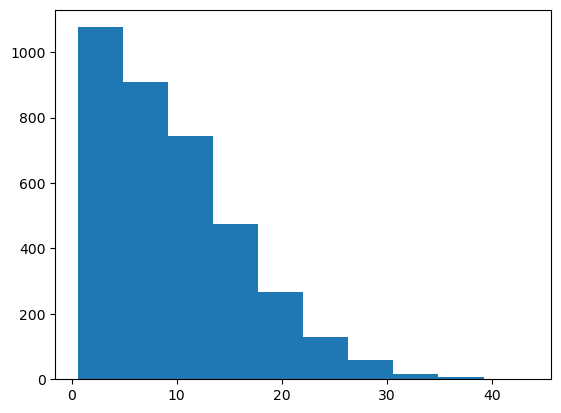

In [300]:
plt.hist(np.array(real_results)[:, 0])